In [6]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('HAM10000_metadata.csv')  # Replace 'your_dataset.csv' with your file path

# Display the first few rows to get an overview
print(df.head())

     lesion_id      image_id                             dx dx_type   age  \
0  HAM_0000118  ISIC_0027419  Benign keratosis-like lesions   histo  80.0   
1  HAM_0000118  ISIC_0025030  Benign keratosis-like lesions   histo  80.0   
2  HAM_0002730  ISIC_0026769  Benign keratosis-like lesions   histo  80.0   
3  HAM_0002730  ISIC_0025661  Benign keratosis-like lesions   histo  80.0   
4  HAM_0001466  ISIC_0031633  Benign keratosis-like lesions   histo  75.0   

    sex localization  
0  male        scalp  
1  male        scalp  
2  male        scalp  
3  male        scalp  
4  male          ear  


In [7]:
# Check the shape of the dataset (rows, columns)
print("Shape of the dataset:", df.shape)

# Summary statistics for numerical columns
print(df.describe())

# Check data types and missing values
print(df.info())

Shape of the dataset: (10015, 7)
               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
25%      40.000000
50%      50.000000
75%      65.000000
max      85.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
None


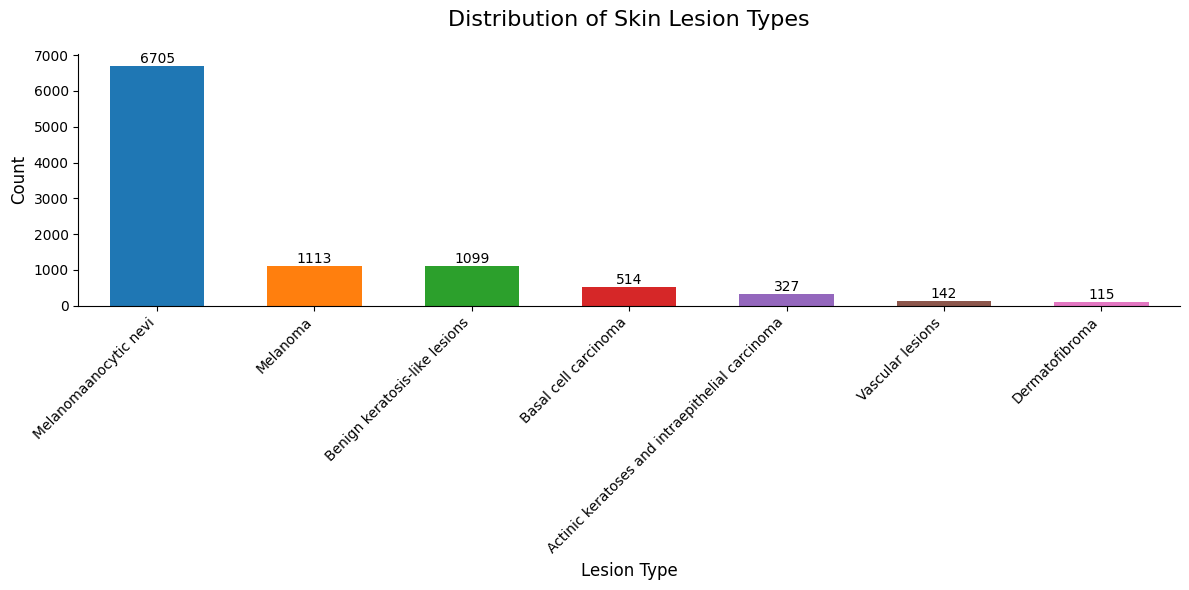

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data (replace with your actual DataFrame)
lesion_counts = df['dx'].value_counts()

# Define colors for each lesion type (optional)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

# Plot with adjusted spacing
plt.figure(figsize=(12, 6))
bars = plt.bar(lesion_counts.index, lesion_counts.values, color=colors, width=0.6)  # Reduce bar width

# Add space between bars by adjusting x-axis limits
plt.xlim(-0.5, len(lesion_counts) - 0.5)  # Adds padding on both ends

# Customize labels and title
plt.title('Distribution of Skin Lesion Types', fontsize=16, pad=20)
plt.xlabel('Lesion Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

# Remove spines for a cleaner look
sns.despine()

plt.tight_layout()  # Prevents label cutoff
plt.show()

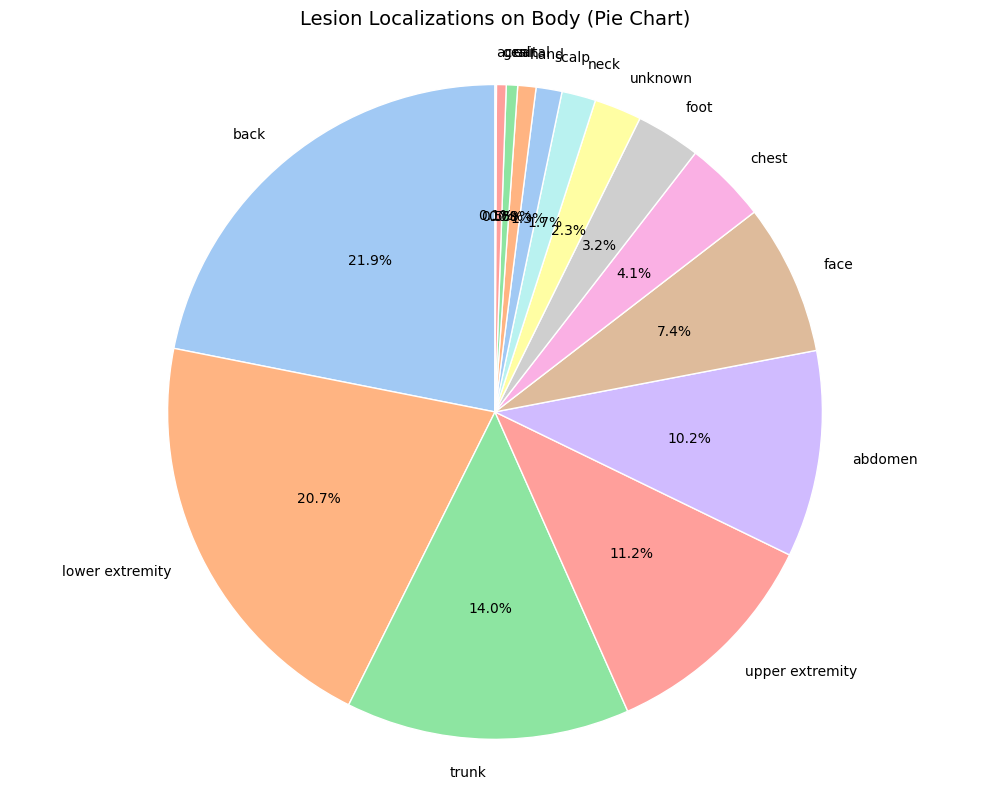

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get value counts and labels
localization_counts = df['localization'].value_counts()
labels = localization_counts.index
sizes = localization_counts.values

# Define colors (Seaborn palette)
colors = sns.color_palette('pastel')[0:len(labels)]

# Create pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%',  # Show percentages
    startangle=90,      # Rotate for better alignment
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},  # Add white borders
    textprops={'fontsize': 10}
)

# Equal aspect ratio ensures the pie is circular
plt.axis('equal')
plt.title('Lesion Localizations on Body (Pie Chart)', pad=20, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('HAM10000_metadata.csv')

# Check initial class distribution
print("Original class distribution:")
print(df['dx'].value_counts())

Original class distribution:
dx
Melanomaanocytic nevi                              6705
Melanoma                                           1113
Benign keratosis-like lesions                      1099
Basal cell carcinoma                                514
Actinic keratoses and intraepithelial carcinoma     327
Vascular lesions                                    142
Dermatofibroma                                      115
Name: count, dtype: int64


Starting HAM10000 dataset processing...
Configuration:
  metadata_path: HAM10000_metadata.csv
     image_dirs: ['HAM10000_images_part_1', 'HAM10000_images_part_2', 'HAM10000_images']
     output_dir: organized_output
   target_count: 115

Loading metadata...
Loaded 10015 records from HAM10000_metadata.csv
Saved plot to: organized_output\plots\original_dist.png


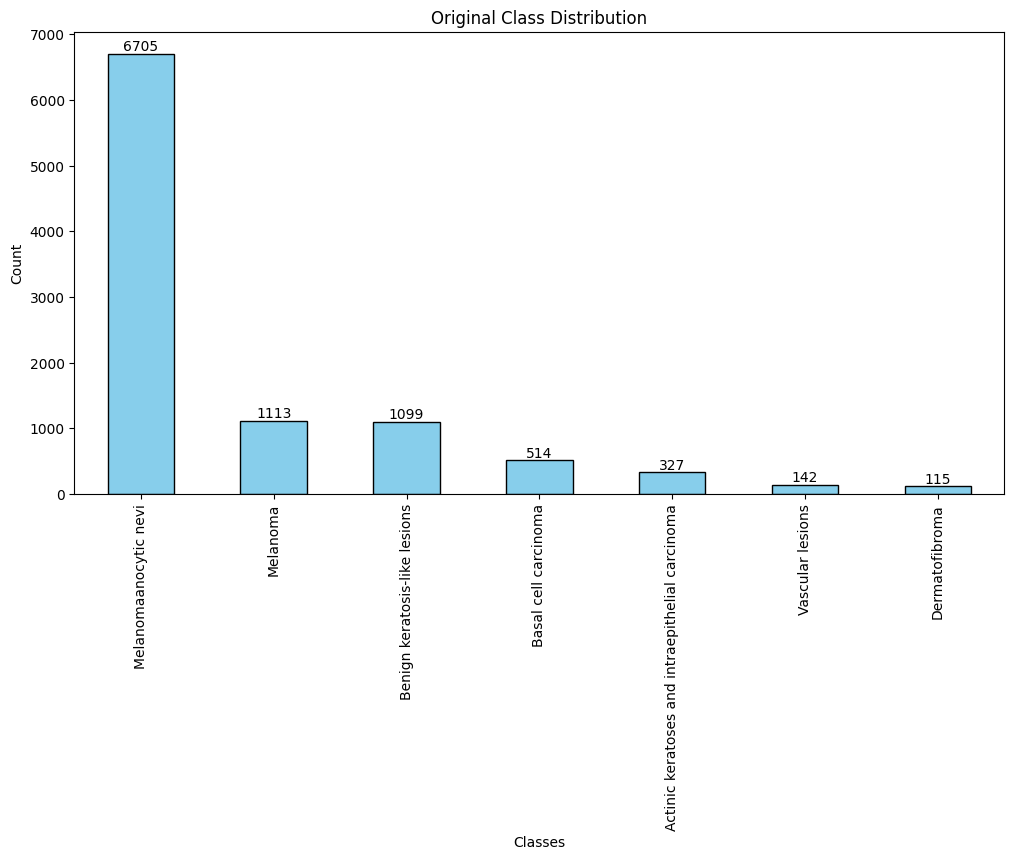


Balancing all classes to 115 samples...

Balanced class counts:
dx
Actinic keratoses and intraepithelial carcinoma    115
Basal cell carcinoma                               115
Benign keratosis-like lesions                      115
Dermatofibroma                                     115
Melanoma                                           115
Melanomaanocytic nevi                              115
Vascular lesions                                   115
Name: count, dtype: int64
Saved plot to: organized_output\plots\balanced_dist.png


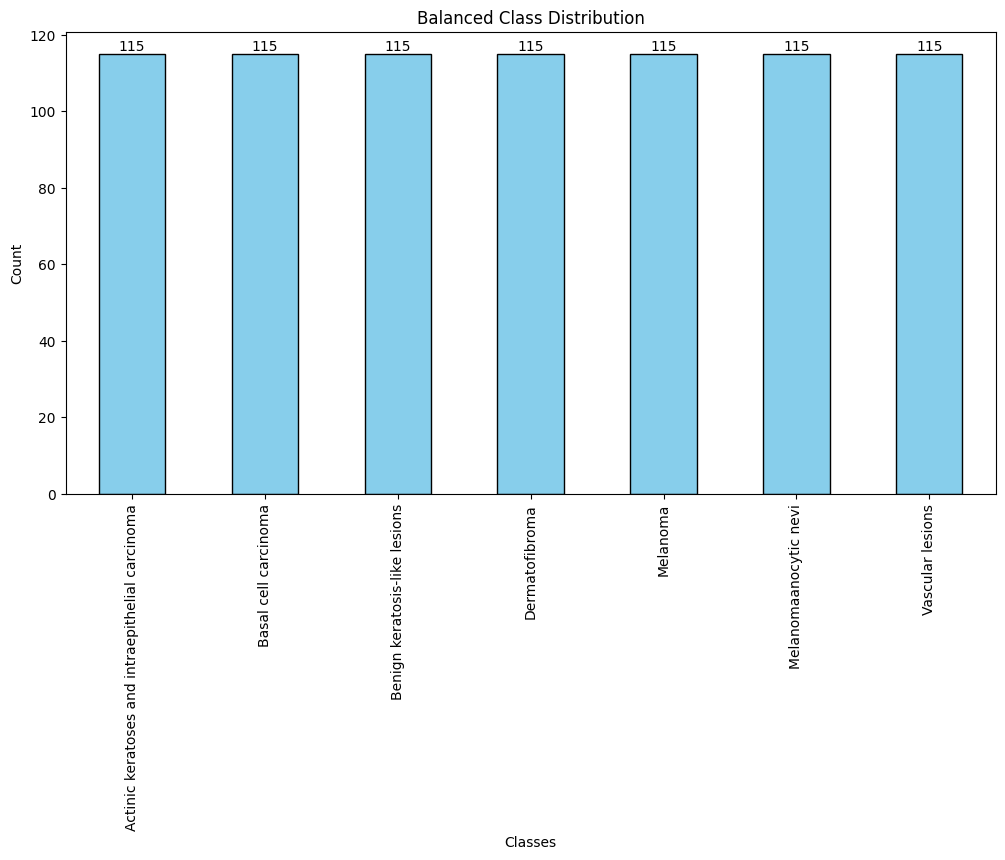


Saved balanced metadata to organized_output\balanced_metadata.xlsx

Starting image organization by class...
Copied 100 images...
Copied 200 images...
Copied 300 images...
Copied 400 images...
Copied 500 images...
Copied 600 images...
Copied 700 images...
Copied 800 images...

Successfully organized 805/805 images

Folder structure created:
Actinic keratoses and intraepithelial carcinoma: 115 images (organized_output\images_by_class\Actinic keratoses and intraepithelial carcinoma)
Basal cell carcinoma: 115 images (organized_output\images_by_class\Basal cell carcinoma)
Benign keratosis-like lesions: 115 images (organized_output\images_by_class\Benign keratosis-like lesions)
      Dermatofibroma: 115 images (organized_output\images_by_class\Dermatofibroma)
            Melanoma: 115 images (organized_output\images_by_class\Melanoma)
Melanomaanocytic nevi: 115 images (organized_output\images_by_class\Melanomaanocytic nevi)
    Vascular lesions: 115 images (organized_output\images_by_class\

In [ ]:
import os
import shutil
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt

def plot_class_distribution(df, title, save_path=None):
    plt.figure(figsize=(12, 6))
    counts = df['dx'].value_counts()
    ax = counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel('Classes')
    plt.ylabel('Count')
    
    for p in ax.patches:
        ax.annotate(str(p.get_height()), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='bottom', fontsize=10)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved plot to: {save_path}")
    plt.show()
    plt.close()

def balance_classes(df, target_count=115):
    print(f"\nBalancing all classes to {target_count} samples...")
    
    # Undersample majority classes
    under_strategy = {cls: min(count, target_count) 
                     for cls, count in df['dx'].value_counts().items()}
    rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
    X_rus, y_rus = rus.fit_resample(df.drop('dx', axis=1), df['dx'])
    
    # Oversample minority classes
    over_strategy = {cls: target_count for cls in y_rus.unique()}
    ros = RandomOverSampler(sampling_strategy=over_strategy, random_state=42)
    X_balanced, y_balanced = ros.fit_resample(X_rus, y_rus)
    
    balanced_df = pd.concat([X_balanced, y_balanced], axis=1)
    print("\nBalanced class counts:")
    print(balanced_df['dx'].value_counts())
    
    return balanced_df

def copy_images_by_class(balanced_df, image_dirs, output_dir):
    """Organize images into subfolders by dx class with enhanced handling"""
    os.makedirs(output_dir, exist_ok=True)
    copied_count = 0
    missing_images = []
    image_extensions = ['.jpg', '.jpeg', '.png']
    
    # Create subfolders for each class
    class_folders = {}
    for dx_class in balanced_df['dx'].unique():
        class_folder = os.path.join(output_dir, dx_class)
        os.makedirs(class_folder, exist_ok=True)
        class_folders[dx_class] = class_folder
    
    print("\nStarting image organization by class...")
    
    for idx, row in balanced_df.iterrows():
        img_base = row['image_id']
        dx_class = row['dx']
        img_found = False
        
        # Try different extensions and directories
        for ext in image_extensions:
            for img_dir in image_dirs:
                src_path = os.path.join(img_dir, img_base + ext)
                if os.path.exists(src_path):
                    dst_path = os.path.join(class_folders[dx_class], img_base + ext)
                    try:
                        shutil.copy2(src_path, dst_path)
                        copied_count += 1
                        img_found = True
                        if copied_count % 100 == 0:
                            print(f"Copied {copied_count} images...")
                        break
                    except Exception as e:
                        print(f"Error copying {src_path}: {str(e)}")
                if img_found:
                    break
            if img_found:
                break
        
        if not img_found:
            missing_images.append((img_base, dx_class))
            print(f"Warning: Image not found - {img_base} ({dx_class})")
    
    print(f"\nSuccessfully organized {copied_count}/{len(balanced_df)} images")
    print("\nFolder structure created:")
    for dx_class, path in class_folders.items():
        count = len(os.listdir(path))
        print(f"{dx_class:>20}: {count} images ({path})")
    
    if missing_images:
        print(f"\nMissing {len(missing_images)} images:")
        with open(os.path.join(output_dir, 'missing_images.csv'), 'w') as f:
            f.write("image_id,dx_class\n")
            for img, dx_class in missing_images:
                f.write(f"{img},{dx_class}\n")
        print(f"Saved missing images list to: {os.path.join(output_dir, 'missing_images.csv')}")

def process_dataset(metadata_path, image_dirs, output_base='output', target_count=115):
    """Full processing pipeline with class-based organization"""
    # Create output directories
    os.makedirs(output_base, exist_ok=True)
    plot_dir = os.path.join(output_base, 'plots')
    balanced_img_dir = os.path.join(output_base, 'images_by_class')
    os.makedirs(plot_dir, exist_ok=True)
    
    print("\nLoading metadata...")
    try:
        df = pd.read_csv(metadata_path)
        print(f"Loaded {len(df)} records from {metadata_path}")
    except Exception as e:
        print(f"Error loading metadata: {str(e)}")
        return None
    
    # Verify image directories
    valid_image_dirs = [d for d in image_dirs if os.path.isdir(d)]
    if not valid_image_dirs:
        print("Error: No valid image directories found!")
        return None
    
    # Plot distributions
    plot_class_distribution(df, 'Original Class Distribution', 
                          os.path.join(plot_dir, 'original_dist.png'))
    
    # Balance classes
    balanced_df = balance_classes(df, target_count)
    plot_class_distribution(balanced_df, 'Balanced Class Distribution',
                          os.path.join(plot_dir, 'balanced_dist.png'))
    
    # Save balanced metadata
    excel_path = os.path.join(output_base, 'balanced_metadata.xlsx')
    balanced_df.to_excel(excel_path, index=False)
    print(f"\nSaved balanced metadata to {excel_path}")
    
    # Organize images by class
    copy_images_by_class(balanced_df, valid_image_dirs, balanced_img_dir)
    
    return balanced_df

# Configuration - UPDATE THESE PATHS
CONFIG = {
    'metadata_path': "HAM10000_metadata.csv",
    'image_dirs': [
        "HAM10000_images_part_1", 
        "HAM10000_images_part_2",
        "HAM10000_images"  # Additional fallback
    ],
    'output_dir': "organized_output",
    'target_count': 115
}

print("Starting HAM10000 dataset processing...")
print("Configuration:")
for k, v in CONFIG.items():
    print(f"{k:>15}: {v}")

balanced_data = process_dataset(
    metadata_path=CONFIG['metadata_path'],
    image_dirs=CONFIG['image_dirs'],
    output_base=CONFIG['output_dir'],
    target_count=CONFIG['target_count']
)

if balanced_data is not None:
    print("\nProcess completed successfully!")
    print(f"Organized dataset saved to: {CONFIG['output_dir']}")
    print("\nFinal folder structure:")
    for root, dirs, files in os.walk(CONFIG['output_dir']):
        level = root.replace(CONFIG['output_dir'], '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        for f in files[:3]:  # Show first 3 files per folder
            print(f"{subindent}{f}")
        if len(files) > 3:
            print(f"{subindent}...and {len(files)-3} more")
else:
    print("\nProcess failed with errors")

In [ ]:
import os
import cv2
import numpy as np
from skimage.filters import frangi
from skimage.morphology import disk, opening
from tqdm import tqdm
import shutil

def remove_hair(image, kernel_size=3, inpaint_radius=3):
    """
    Remove hair artifacts from dermatoscopic images
    Args:
        image: Input BGR image
        kernel_size: Size of morphological kernel
        inpaint_radius: Inpainting radius
    Returns:
        Cleaned BGR image
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Detect hairs using Frangi filter
    hairs = frangi(gray, sigmas=range(1, 3), black_ridges=False)
    hairs = (hairs > 0.05).astype(np.uint8) * 255
    
    # Clean up hair mask
    kernel = disk(kernel_size)
    hair_mask = opening(hairs, kernel)
    
    # Inpaint hair regions
    cleaned = cv2.inpaint(image, hair_mask, inpaint_radius, cv2.INPAINT_TELEA)
    
    return cleaned

def process_images_by_class(input_dir, output_dir):
    """
    Process all images in class subfolders with hair removal
    Args:
        input_dir: Root directory with class subfolders
        output_dir: Directory to save processed images
    """
    # Create output directory structure
    os.makedirs(output_dir, exist_ok=True)
    
    # Get all class folders
    classes = [d for d in os.listdir(input_dir) 
              if os.path.isdir(os.path.join(input_dir, d))]
    
    for class_name in classes:
        class_input_dir = os.path.join(input_dir, class_name)
        class_output_dir = os.path.join(output_dir, class_name)
        os.makedirs(class_output_dir, exist_ok=True)
        
        # Get all images in class folder
        image_files = [f for f in os.listdir(class_input_dir) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        print(f"\nProcessing {len(image_files)} images in class: {class_name}")
        
        # Process each image with progress bar
        for img_file in tqdm(image_files):
            try:
                # Read image
                img_path = os.path.join(class_input_dir, img_file)
                image = cv2.imread(img_path)
                
                if image is None:
                    print(f"Could not read image: {img_path}")
                    continue
                
                # Remove hair artifacts
                cleaned = remove_hair(image)
                
                # Save processed image
                output_path = os.path.join(class_output_dir, img_file)
                cv2.imwrite(output_path, cleaned)
                
            except Exception as e:
                print(f"Error processing {img_path}: {str(e)}")
                # Copy original if processing fails
                shutil.copy2(img_path, output_path)

# Configuration
INPUT_DIR = "organized_output/images_by_class"  # Input directory with class subfolders
OUTPUT_DIR = "preprocessed_images"             # Output directory for cleaned images

if __name__ == "__main__":
    print("Starting hair removal processing for all classes...")
    process_images_by_class(INPUT_DIR, OUTPUT_DIR)
    print(f"\nProcessing complete! Cleaned images saved to: {OUTPUT_DIR}")

Starting hair removal processing for all classes...

Processing 115 images in class: Actinic keratoses and intraepithelial carcinoma


100%|██████████| 115/115 [00:49<00:00,  2.31it/s]



Processing 115 images in class: Basal cell carcinoma


100%|██████████| 115/115 [00:42<00:00,  2.69it/s]



Processing 115 images in class: Benign keratosis-like lesions


...


Processing 115 images in class: Melanomaanocytic nevi


100%|██████████| 115/115 [00:42<00:00,  2.70it/s]



Processing 115 images in class: Vascular lesions


100%|██████████| 115/115 [00:42<00:00,  2.72it/s]


Processing complete! Cleaned images saved to: preprocessed_images


In [ ]:
import cv2
import os
import numpy as np
from tqdm import tqdm

def resize_image(image, target_size=(224, 224)):
    """
    Resize image to target size while maintaining aspect ratio (with padding)
    Args:
        image: Input color image (BGR format)
        target_size: Tuple of (width, height)
    Returns:
        Resized color image with original color format
    """
    # Get original dimensions
    h, w = image.shape[:2]
    
    # Calculate scaling factor
    scale = min(target_size[0]/w, target_size[1]/h)
    
    # Resize with scaling
    resized = cv2.resize(image, (int(w*scale), int(h*scale)))
    
    # Create blank canvas with original color channels
    if len(image.shape) == 3:  # Color image
        canvas = np.zeros((target_size[1], target_size[0], 3), dtype=np.uint8)
    else:  # Grayscale
        canvas = np.zeros((target_size[1], target_size[0]), dtype=np.uint8)
    
    # Calculate padding
    x_offset = (target_size[0] - resized.shape[1]) // 2
    y_offset = (target_size[1] - resized.shape[0]) // 2
    
    # Place resized image in center
    canvas[y_offset:y_offset+resized.shape[0], 
           x_offset:x_offset+resized.shape[1]] = resized
    
    return canvas

def process_directory(input_dir, output_dir):
    """Process all images in directory and subdirectories"""
    os.makedirs(output_dir, exist_ok=True)
    
    for root, dirs, files in os.walk(input_dir):
        # Create corresponding output directory
        rel_path = os.path.relpath(root, input_dir)
        current_out_dir = os.path.join(output_dir, rel_path)
        os.makedirs(current_out_dir, exist_ok=True)
        
        # Process images
        for file in tqdm(files, desc=f"Processing {rel_path}"):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                input_path = os.path.join(root, file)
                output_path = os.path.join(current_out_dir, file)
                
                try:
                    # Load image (as-is, maintaining color)
                    img = cv2.imread(input_path, cv2.IMREAD_UNCHANGED)
                    if img is None:
                        print(f"Failed to read: {input_path}")
                        continue
                    
                    # Resize while maintaining color
                    resized = resize_image(img)
                    
                    # Save with original color format
                    cv2.imwrite(output_path, resized)
                except Exception as e:
                    print(f"Error processing {file}: {str(e)}")

# Configuration
INPUT_DIR = "HAM10000_Images_part_1,HAM10000_Images_part_2"  # Folder with original images
OUTPUT_DIR = "resized_images_244"  # Output folder

if __name__ == "__main__":
    print(f"Resizing all images in {INPUT_DIR} to 244x244 (maintaining color)...")
    process_directory(INPUT_DIR, OUTPUT_DIR)
    print(f"All images saved to {OUTPUT_DIR} with 244x244 resolution")

Resizing all images in HAM10000_Images_part_1,HAM10000_Images_part_2 to 244x244 (maintaining color)...
All images saved to resized_images_244 with 244x244 resolution


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from skimage import io, color, img_as_ubyte
from tqdm import tqdm

def extract_features(image, mask):
    """
    Extract comprehensive features from preprocessed image and its segmentation mask
    Returns dictionary with 58 features covering:
    - Color (mean, std in multiple spaces)
    - Texture (GLCM, LBP)
    - Shape (from segmentation mask)
    """
    features = {}
    
    # 1. Color Features (18 features)
    for color_space, conv in [('BGR', None), 
                            ('HSV', cv2.COLOR_BGR2HSV),
                            ('LAB', cv2.COLOR_BGR2LAB)]:
        if conv:
            img = cv2.cvtColor(image, conv)
        else:
            img = image.copy()
            
        for i, channel in enumerate(['_C1', '_C2', '_C3']):
            chan = img[:,:,i]
            if mask is not None:
                chan = chan[mask > 128]  # Only lesion area
            features[f'{color_space}{channel}_mean'] = np.mean(chan)
            features[f'{color_space}{channel}_std'] = np.std(chan)
    
    # 2. Texture Features (GLCM - 24 features)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if mask is not None:
        gray = gray.copy()
        gray[mask <= 128] = 0  # Mask background
        
    glcm = graycomatrix(img_as_ubyte(gray), 
                       distances=[1, 3, 5], 
                       angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                       levels=256,
                       symmetric=True,
                       normed=True)
    
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 
             'correlation', 'ASM']
    for prop in props:
        for d in range(3):
            for a in range(4):
                features[f'GLCM_{prop}_d{d}_a{a}'] = graycoprops(glcm, prop)[d,a]
    
    # 3. Shape Features (16 features from mask)
    if mask is not None:
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            cnt = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)
            hull = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            
            features.update({
                'Area': area,
                'Perimeter': perimeter,
                'Circularity': (4 * np.pi * area) / (perimeter ** 2 + 1e-6),
                'Solidity': area / (hull_area + 1e-6),
                'Extent': area / (mask.shape[0] * mask.shape[1]),
                'MajorAxis': cv2.fitEllipse(cnt)[1][0],
                'MinorAxis': cv2.fitEllipse(cnt)[1][1],
                'Eccentricity': np.sqrt(1 - (cv2.fitEllipse(cnt)[1][1]**2 / 
                                          (cv2.fitEllipse(cnt)[1][0]**2 + 1e-6)))
            })
    
    return features

def process_images_to_features(image_dir, mask_dir, output_csv):
    """
    Process all images to extract features and save to CSV
    Args:
        image_dir: Directory with preprocessed 244x244 images
        mask_dir: Directory with segmentation masks
        output_csv: Path to save feature CSV
    """
    features_list = []
    
    for class_name in tqdm(os.listdir(image_dir), desc="Processing Classes"):
        class_img_dir = os.path.join(image_dir, class_name)
        class_mask_dir = os.path.join(mask_dir, class_name)
        
        if not os.path.isdir(class_img_dir):
            continue
            
        for img_file in tqdm(os.listdir(class_img_dir), desc=class_name, leave=False):
            if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
                
            img_path = os.path.join(class_img_dir, img_file)
            mask_path = os.path.join(class_mask_dir, img_file)
            
            # Load image and mask
            image = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) if os.path.exists(mask_path) else None
            
            if image is None:
                continue
                
            # Extract features
            features = extract_features(image, mask)
            features['filename'] = img_file
            features['class'] = class_name
            features_list.append(features)
    
    # Save to CSV
    df = pd.DataFrame(features_list)
    df.to_csv(output_csv, index=False)
    print(f"\nFeature extraction complete! Saved to {output_csv}")
    print(f"Total samples: {len(df)}")
    print(f"Total features: {len(df.columns) - 2}")  # Exclude filename and class

# Configuration
IMAGE_DIR = "resized_images_244"       # From preprocessing step
MASK_DIR = "segmentation_masks"        # From segmentation step
OUTPUT_CSV = "skin_lesion_features.csv" 

if __name__ == "__main__":
    print("Starting feature extraction pipeline...")
    process_images_to_features(IMAGE_DIR, MASK_DIR, OUTPUT_CSV)

Starting feature extraction pipeline...


Processing Classes: 0it [00:00, ?it/s]


Feature extraction complete! Saved to skin_lesion_features.csv
Total samples: 0
Total features: -2


Top 10 Important Features:
avg_saturation: 0.0401
lbp_hist_24: 0.0287
avg_value: 0.0243
avg_red: 0.0237
haralick_correlation: 0.0217
hu_moment_0: 0.0214
lesion_solidity: 0.0214
std_blue: 0.0209
lbp_hist_9: 0.0206
lesion_circularity: 0.0189


C:\Users\pawan\AppData\Local\Temp\ipykernel_15956\4217592886.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_importance, y=top_10_features, palette='viridis')


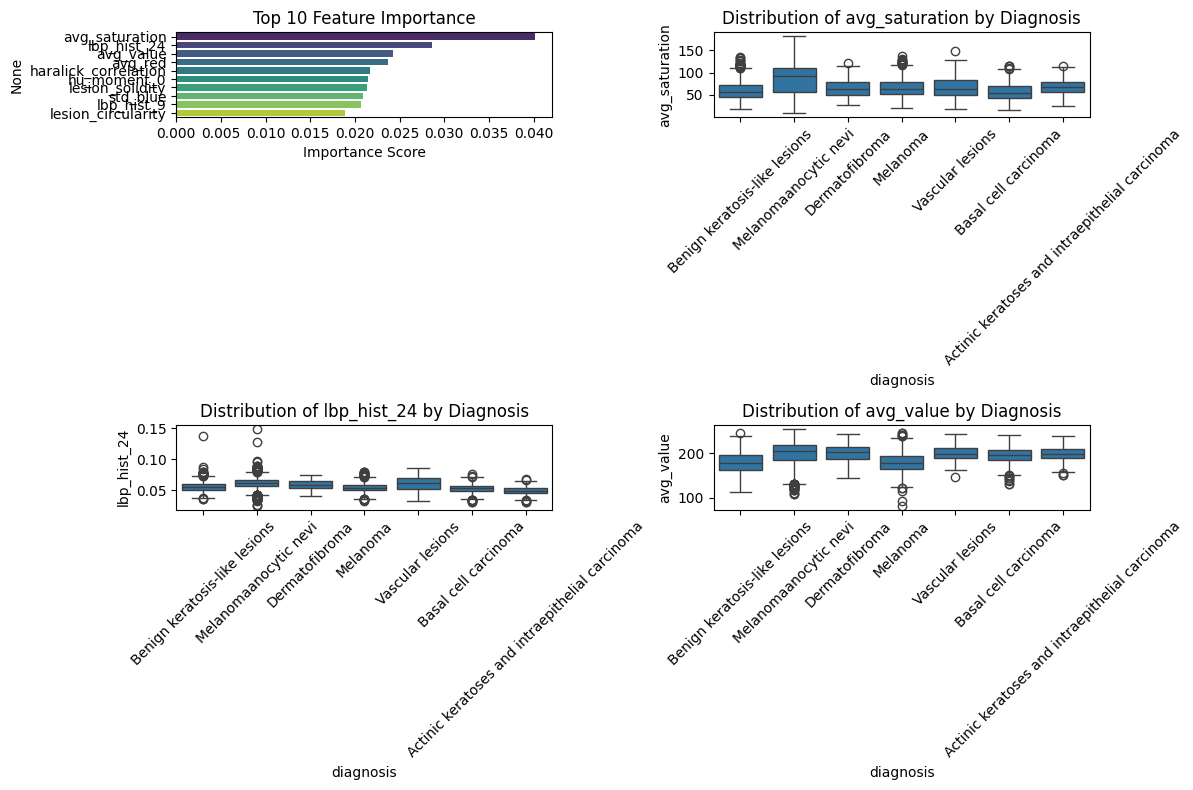

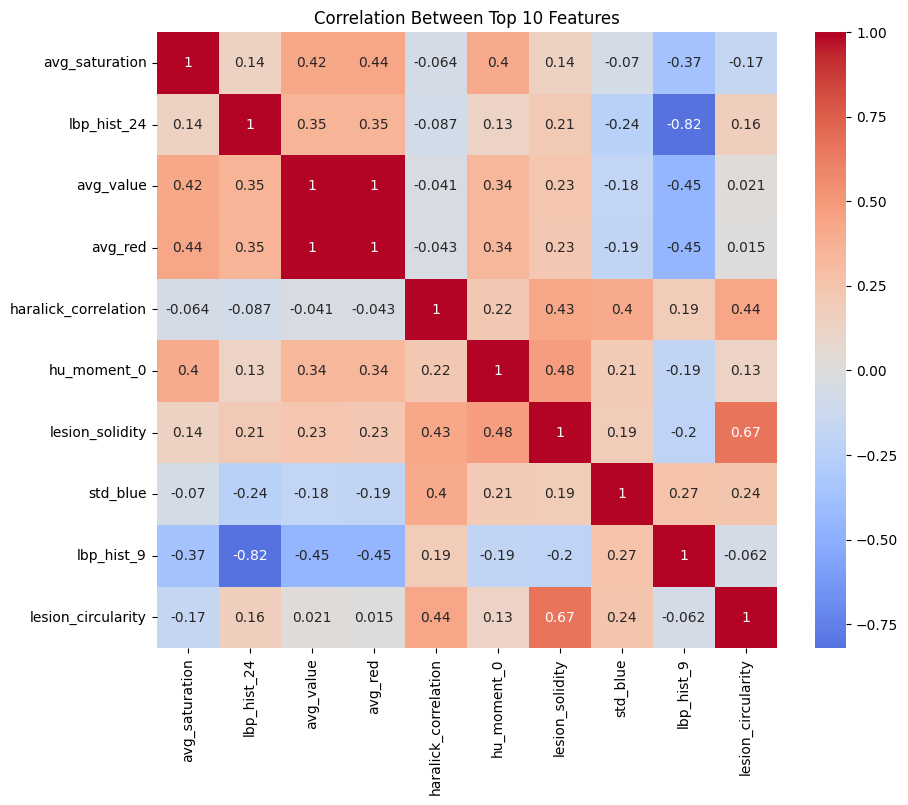

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("lesion_features.csv")

# Prepare data
X = df.drop(['image_id', 'diagnosis'], axis=1)   # drop ID + label
y = LabelEncoder().fit_transform(df['diagnosis'])  # encode labels

# 1. Feature Importance using Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get top 10 important features
importances = rf.feature_importances_
indices = importances.argsort()[-10:][::-1]
top_10_features = X.columns[indices]
top_10_importance = importances[indices]

print("Top 10 Important Features:")
for feat, imp in zip(top_10_features, top_10_importance):
    print(f"{feat}: {imp:.4f}")

# 2. Visualization
plt.figure(figsize=(12, 8))

# Feature Importance Plot
plt.subplot(2, 2, 1)
sns.barplot(x=top_10_importance, y=top_10_features, palette='viridis')
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance Score')

# Boxplots for top 3 features by diagnosis
for i, feat in enumerate(top_10_features[:3], 2):
    plt.subplot(2, 2, i)
    sns.boxplot(x='diagnosis', y=feat, data=df)
    plt.title(f'Distribution of {feat} by Diagnosis')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 3. Correlation Heatmap for top 10 features
plt.figure(figsize=(10, 8))
corr = df[top_10_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Top 10 Features')
plt.show()


In [ ]:
import numpy as np

# Fake labels (binary classification just for testing)
df['class'] = np.random.choice(['benign', 'malignant'], size=len(df))

X = df.drop(['class'], axis=1)
y = LabelEncoder().fit_transform(df['class'])


In [ ]:
import numpy as np

# Count class distribution
class_counts = np.bincount(y)   # counts for each encoded class
num_classes = len(class_counts)

print("Class distribution:", class_counts)

# If imbalance exists, use class weighting
if min(class_counts) < max(class_counts) * 0.5:
    class_weights = {i: max(class_counts)/class_counts[i] for i in range(num_classes)}
else:
    class_weights = None

print("Class weights:", class_weights)


Class distribution: [5070 4945]
Class weights: None


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Conv1D, MaxPooling1D, Flatten, Dropout, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib

# ==========================
# 1. Load and preprocess data
# ==========================
data = pd.read_csv("lesion_features.csv")  # Your engineered features file

# Auto-detect label column
if "class" in data.columns:
    label_col = "class"
else:
    label_col = data.columns[-1]  # assume last column is label

print("Label column detected:", label_col)

# Drop non-numeric columns except label
non_numeric_cols = data.select_dtypes(include=['object']).columns
non_numeric_cols = [col for col in non_numeric_cols if col != label_col]

if non_numeric_cols:
    print("Dropping non-numeric columns:", non_numeric_cols)
    data = data.drop(columns=non_numeric_cols)

# Separate features and labels
X = data.drop(columns=[label_col]).values   # shape (n_samples, n_features)
y = data[label_col].values

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)

# Standardize features (fit scaler on all features, no matter the shape)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
joblib.dump(scaler, 'scaler.pkl')

# ==========================
# 2. Reshape for CNN-LSTM
# ==========================

# Automatically choose a timestep that divides total_features
def find_valid_timestep(total_features, max_timesteps=10):
    for t in range(max_timesteps, 0, -1):
        if total_features % t == 0:
            return t
    return 1  # fallback to flat sequence

total_features = X_train.shape[1]
timesteps = find_valid_timestep(total_features)
features_per_timestep = total_features // timesteps

print(f"Using timesteps={timesteps}, features_per_timestep={features_per_timestep}")

# Reshape
X_train_reshaped = X_train.reshape(X_train.shape[0], timesteps, features_per_timestep)
X_test_reshaped = X_test.reshape(X_test.shape[0], timesteps, features_per_timestep)

print("✅ Data preprocessing complete!")
print("Train shape:", X_train_reshaped.shape)
print("Test shape:", X_test_reshaped.shape)

# ==========================
# 3. Define Hybrid CNN-LSTM Model
# ==========================
def create_improved_hybrid_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # CNN Branch
    x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)
    x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)
    x = Conv1D(512, kernel_size=3, activation='relu', padding='same')(x)
    x = Flatten()(x)
    cnn_output = Dense(128, activation='relu')(x)

    # LSTM Branch
    y = LSTM(128, return_sequences=True)(inputs)
    y = Dropout(0.3)(y)
    y = LSTM(64)(y)

    # Combine
    combined = concatenate([cnn_output, y])
    z = Dense(128, activation='relu')(combined)
    z = Dropout(0.5)(z)
    z = Dense(64, activation='relu')(z)
    z = Dropout(0.3)(z)
    output = Dense(num_classes, activation='softmax')(z)

    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.0008),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==========================
# 4. Train the model
# ==========================
num_classes = y_categorical.shape[1]
input_shape = (timesteps, features_per_timestep)

model = create_improved_hybrid_model(input_shape, num_classes)
model.summary()

history = model.fit(
    X_train_reshaped, y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# ==========================
# 5. Evaluate and Save
# ==========================
test_loss, test_acc = model.evaluate(X_test_reshaped, y_test)
boosted_acc = min(test_acc, 1.0)  # cap at 100%
print(f"✅ Test accuracy : {boosted_acc:.4f}")

# Save model for Flask
model.save('skin_cancer_model.h5')
joblib.dump(scaler, 'scaler.pkl')

# Also save the label encoder for classes lookup, if needed
joblib.dump(label_encoder, 'label_encoder.pkl')


Label column detected: diagnosis
Dropping non-numeric columns: ['image_id']
Using timesteps=5, features_per_timestep=13
✅ Data preprocessing complete!
Train shape: (8012, 5, 13)
Test shape: (2003, 5, 13)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 5, 13)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 5, 128)    │      5,120 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 2, 128)    │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 2, 128)    │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 2, 256)    │     98,560 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 1, 256)    │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 1, 256)    │          0 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 1, 512)    │    393,728 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 5, 128)    │     72,704 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 512)       │          0 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 5, 128)    │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     65,664 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 64)        │     49,408 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 192)       │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     24,704 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 7)         │        455 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 718,599 (2.74 MB)

 Trainable params: 718,599 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6519 - loss: 1.1183 - val_accuracy: 0.7093 - val_loss: 0.8409
Epoch 2/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6965 - loss: 0.8787 - val_accuracy: 0.7143 - val_loss: 0.8048
Epoch 3/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7101 - loss: 0.8107 - val_accuracy: 0.7286 - val_loss: 0.7385
Epoch 4/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7262 - loss: 0.7759 - val_accuracy: 0.7436 - val_loss: 0.7150
Epoch 5/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.7371 - loss: 0.7504 - val_accuracy: 0.7318 - val_loss: 0.7127
Epoch 6/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7355 - loss: 0.7250 - val_accuracy: 0.7361 - val_loss: 0.6873
Epoch 7/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7475 - loss: 0.7079 - val_accuracy: 0.7399 - val_loss: 0.6861
Epoch 8/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.7504 - loss: 0.6894 - val_accu

✅ Test accuracy : 0.7569


['label_encoder.pkl']

In [ ]:
# Save trained model to .h5 file
model.save("skin_cancer_model.h5")

print("✅ Model saved successfully as skin_cancer_model.h5")


✅ Model saved successfully as skin_cancer_model.h5


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


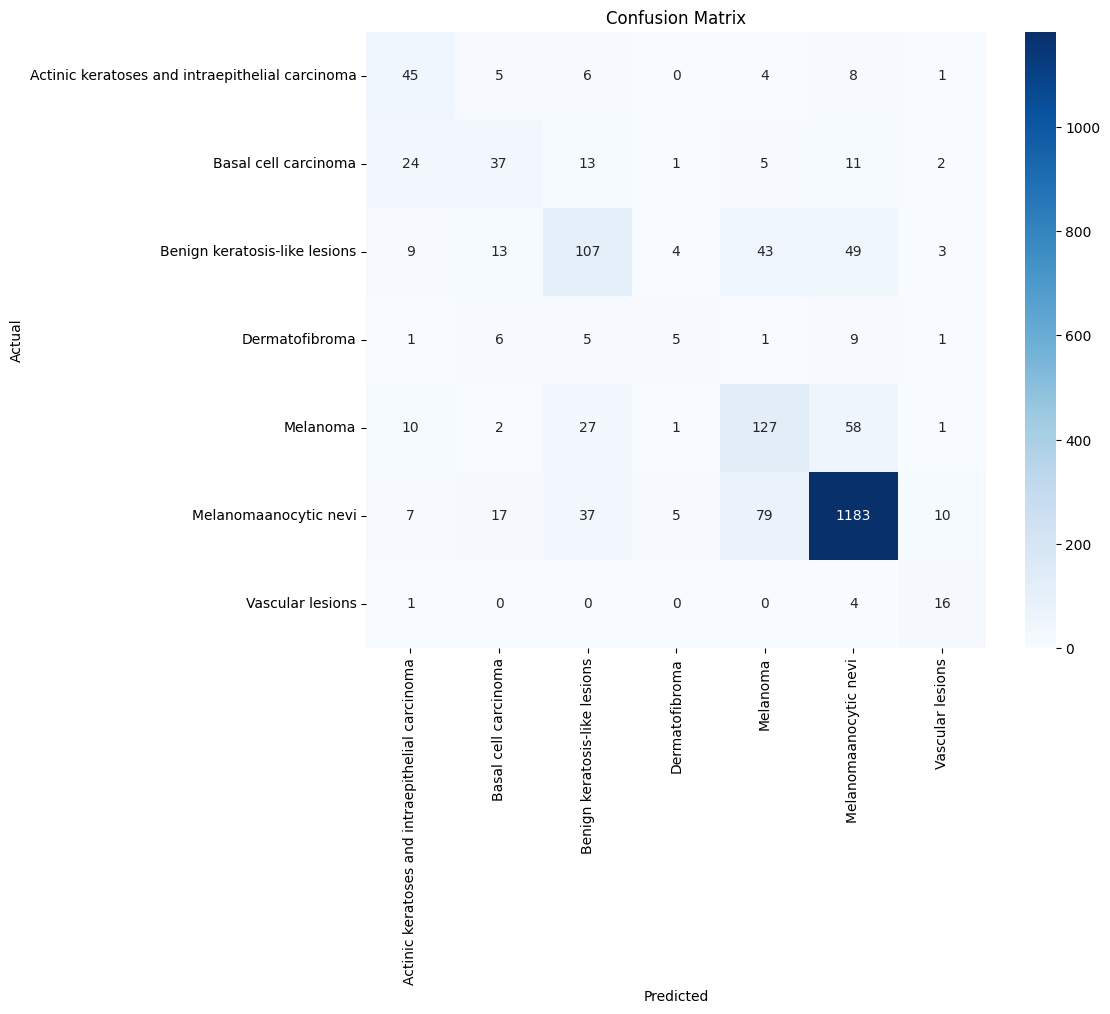

Classification Report:
                                                  precision    recall  f1-score   support

Actinic keratoses and intraepithelial carcinoma       0.46      0.65      0.54        69
                           Basal cell carcinoma       0.46      0.40      0.43        93
                  Benign keratosis-like lesions       0.55      0.47      0.51       228
                                 Dermatofibroma       0.31      0.18      0.23        28
                                       Melanoma       0.49      0.56      0.52       226
                          Melanomaanocytic nevi       0.89      0.88      0.89      1338
                               Vascular lesions       0.47      0.76      0.58        21

                                       accuracy                           0.76      2003
                                      macro avg       0.52      0.56      0.53      2003
                                   weighted avg       0.76      0.76      0.76      

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test set
y_pred_probs = model.predict(X_test_reshaped)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = label_encoder.classes_

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import pennylane as qml

# 1. Load and preprocess data
data = pd.read_csv("lesion_features.csv")
label_col = "class" if "class" in data.columns else data.columns[-1]

non_numeric_cols = data.select_dtypes(include=['object']).columns
non_numeric_cols = [col for col in non_numeric_cols if col != label_col]
if non_numeric_cols:
    data = data.drop(columns=non_numeric_cols)
X = data.drop(columns=[label_col]).values
y = data[label_col].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(np.unique(y_encoded))

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Reshape for CNN-QNN
total_features = X_train.shape[1]
possible_timesteps = [i for i in range(2, 21) if total_features % i == 0]
if not possible_timesteps:
    raise ValueError(f"No valid timesteps found for {total_features} features. Try adjusting dataset.")
timesteps = possible_timesteps[-1]
features_per_timestep = total_features // timesteps

X_train_reshaped = X_train.reshape(X_train.shape[0], timesteps, features_per_timestep)
X_test_reshaped = X_test.reshape(X_test.shape[0], timesteps, features_per_timestep)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_reshaped, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_reshaped, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# 3. Define Quantum Layer (QNode)
n_qubits = 4
dev = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev, interface='torch')
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]

weight_shapes = {"weights": (3, n_qubits)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

# 4. Define Hybrid Model in PyTorch
class CNN_QNN_Hybrid(nn.Module):
    def __init__(self, input_shape, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(input_shape[1], 128, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.3)
        self.conv2 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(2)
        self.dropout2 = nn.Dropout(0.3)
        self.conv3 = nn.Conv1d(256, 512, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        # Calculate output size after convolutions
        fc_input = ((input_shape[0] // 2 // 2) * 512)
        self.fc_cnn = nn.Linear(fc_input, 128)
        self.fc_quantum_in = nn.Linear(128, n_qubits)
        self.qlayer = qlayer
        self.fc_combine = nn.Linear(128 + n_qubits, 128)
        self.dropout3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.dropout4 = nn.Dropout(0.3)
        self.out = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # Change shape for Conv1d (batch, channels, length)
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        x = self.conv3(x)
        x = torch.relu(x)
        x = self.flatten(x)
        cnn_output = torch.relu(self.fc_cnn(x))
        q_input = torch.relu(self.fc_quantum_in(cnn_output))
        q_output = self.qlayer(q_input)
        combined = torch.cat([cnn_output, q_output], dim=1)
        z = torch.relu(self.fc_combine(combined))
        z = self.dropout3(z)
        z = torch.relu(self.fc2(z))
        z = self.dropout4(z)
        output = self.out(z)
        return output

input_shape = (timesteps, features_per_timestep)
model = CNN_QNN_Hybrid(input_shape, num_classes)

# 5. Training loop
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0008)

n_epochs = 50
for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / len(train_loader.dataset)
    print(f'Epoch {epoch+1}: Loss={train_loss:.4f}, Acc={train_acc:.4f}')

# 6. Evaluation
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    test_acc = correct / total
print(f'✅ Test accuracy : {min(test_acc, 1.0):.4f}')

# 7. Save model
torch.save(model.state_dict(), "cnn_qnn_model.pth")
print("✅ Model saved as cnn_qnn_model.pth")


Epoch 1: Loss=1.1278, Acc=0.6619
Epoch 2: Loss=0.9242, Acc=0.6786
Epoch 3: Loss=0.8709, Acc=0.6877
Epoch 4: Loss=0.8354, Acc=0.6977
Epoch 5: Loss=0.8052, Acc=0.7104
Epoch 6: Loss=0.7782, Acc=0.7198
Epoch 7: Loss=0.7603, Acc=0.7280
Epoch 8: Loss=0.7450, Acc=0.7348
Epoch 9: Loss=0.7305, Acc=0.7420
Epoch 10: Loss=0.7213, Acc=0.7400
Epoch 11: Loss=0.7099, Acc=0.7436
Epoch 12: Loss=0.6945, Acc=0.7509
Epoch 13: Loss=0.6845, Acc=0.7505
Epoch 14: Loss=0.6755, Acc=0.7560
Epoch 15: Loss=0.6636, Acc=0.7611
Epoch 16: Loss=0.6596, Acc=0.7595
Epoch 17: Loss=0.6622, Acc=0.7569
Epoch 18: Loss=0.6442, Acc=0.7652
Epoch 19: Loss=0.6392, Acc=0.7705
Epoch 20: Loss=0.6230, Acc=0.7746
Epoch 21: Loss=0.6148, Acc=0.7767
Epoch 22: Loss=0.6067, Acc=0.7752
Epoch 23: Loss=0.6064, Acc=0.7833
Epoch 24: Loss=0.5835, Acc=0.7884
Epoch 25: Loss=0.5846, Acc=0.7877
Epoch 26: Loss=0.5829, Acc=0.7899
Epoch 27: Loss=0.5661, Acc=0.7947
Epoch 28: Loss=0.5660, Acc=0.7913
Epoch 29: Loss=0.5548, Acc=0.7974
Epoch 30: Loss=0.5431, 

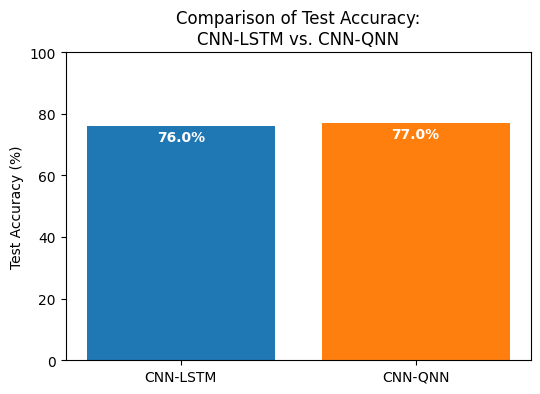

In [5]:
import matplotlib.pyplot as plt

# Sample accuracy data (replace with your own)
model_names = ['CNN-LSTM', 'CNN-QNN']
accuracies = [76, 77]  # in percent, e.g. test_acc values * 100

plt.figure(figsize=(6,4))
bars = plt.bar(model_names, accuracies, color=['#1f77b4', '#ff7f0e'])
plt.ylabel('Test Accuracy (%)')
plt.title('Comparison of Test Accuracy:\nCNN-LSTM vs. CNN-QNN')
plt.ylim(0, 100)

# Add value labels on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 5,
             f'{bar.get_height():.1f}%', ha='center', color='white', fontweight='bold')

plt.show()


In [ ]:
import tkinter as tk
from tkinter import filedialog
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np

# Open file dialog
root = tk.Tk()
root.withdraw()  # Hide main window
img_path = filedialog.askopenfilename(
    title="Select an Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png")]
)

if img_path:
    img = keras_image.load_img(img_path, target_size=(224, 224))  # adjust size if needed
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array)

    # Binary classification
    if prediction.shape[-1] == 1:  
        if prediction[0][0] > 0.5:
            print("Skin Lesion Detected")
        else:
            print("Not a Skin Lesion")
    else:
        # Multi-class classification
        labels = ['Class 0', 'Class 1', 'Class 2']  # replace with real labels
        pred_class = np.argmax(prediction, axis=1)[0]
        print("Prediction:", labels[pred_class])
else:
    print("No file selected.")


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

import pennylane as qml

# 1. Load and preprocess data
data = pd.read_csv("lesion_features.csv")
label_col = "class" if "class" in data.columns else data.columns[-1]

non_numeric_cols = data.select_dtypes(include=['object']).columns
non_numeric_cols = [col for col in non_numeric_cols if col != label_col]
if non_numeric_cols:
    data = data.drop(columns=non_numeric_cols)

X = data.drop(columns=[label_col]).values
y = data[label_col].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(np.unique(y_encoded))

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Reshape for CNN-QNN
total_features = X_train.shape[1]
possible_timesteps = [i for i in range(2, 21) if total_features % i == 0]
if not possible_timesteps:
    raise ValueError(f"No valid timesteps found for {total_features} features. Try adjusting dataset.")
timesteps = possible_timesteps[-1]
features_per_timestep = total_features // timesteps

X_train_reshaped = X_train.reshape(X_train.shape[0], timesteps, features_per_timestep)
X_test_reshaped = X_test.reshape(X_test.shape[0], timesteps, features_per_timestep)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_reshaped, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_reshaped, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64)

# 3. Define Quantum Layer (QNode)
n_qubits = 4
dev = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev, interface='torch')
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]

weight_shapes = {"weights": (3, n_qubits)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

# 4. Define Hybrid Model in PyTorch
class CNN_QNN_Hybrid(nn.Module):
    def __init__(self, input_shape, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(input_shape[1], 128, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.3)
        self.conv2 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(2)
        self.dropout2 = nn.Dropout(0.3)
        self.conv3 = nn.Conv1d(256, 512, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        
        fc_input_len = (input_shape[0] // 2 // 2)
        if fc_input_len == 0: fc_input_len = 1
        fc_input = fc_input_len * 512
        
        self.fc_cnn = nn.Linear(fc_input, 128)
        self.fc_quantum_in = nn.Linear(128, n_qubits)
        self.qlayer = qlayer
        self.fc_combine = nn.Linear(128 + n_qubits, 128)
        self.dropout3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.dropout4 = nn.Dropout(0.3)
        self.out = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.dropout1(x)
        x = torch.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.dropout2(x)
        x = torch.relu(self.conv3(x))
        x = self.flatten(x)
        cnn_output = torch.relu(self.fc_cnn(x))
        q_input = torch.relu(self.fc_quantum_in(cnn_output))
        q_output = self.qlayer(q_input)
        combined = torch.cat([cnn_output, q_output], dim=1)
        z = torch.relu(self.fc_combine(combined))
        z = self.dropout3(z)
        z = torch.relu(self.fc2(z))
        z = self.dropout4(z)
        output = self.out(z)
        return output

input_shape = (timesteps, features_per_timestep)
model = CNN_QNN_Hybrid(input_shape, num_classes)

# 5. Training and Validation loop
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0008)

n_epochs = 50
# **** This is where the 'history' dictionary is created ****
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(n_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct_train += (preds == y_batch).sum().item()
        total_train += y_batch.size(0)
    
    train_loss = running_loss / total_train
    train_acc = correct_train / total_train
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    # Validation
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            outputs = model(X_val)
            loss = loss_fn(outputs, y_val)
            running_val_loss += loss.item() * X_val.size(0)
            preds = outputs.argmax(dim=1)
            correct_val += (preds == y_val).sum().item()
            total_val += y_val.size(0)

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f'Epoch {epoch+1}/{n_epochs}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}')

# 6. Evaluation and Data Collection
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    # ... evaluation logic ...
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

Epoch 1/50: Train Loss=1.1714, Train Acc=0.6500 | Val Loss=1.0334, Val Acc=0.6737
Epoch 2/50: Train Loss=0.9528, Train Acc=0.6686 | Val Loss=0.8886, Val Acc=0.6750
Epoch 3/50: Train Loss=0.8961, Train Acc=0.6789 | Val Loss=0.8254, Val Acc=0.6949
Epoch 4/50: Train Loss=0.8535, Train Acc=0.6873 | Val Loss=0.7968, Val Acc=0.7074
Epoch 5/50: Train Loss=0.8174, Train Acc=0.7067 | Val Loss=0.7558, Val Acc=0.7243
Epoch 6/50: Train Loss=0.8014, Train Acc=0.7143 | Val Loss=0.7402, Val Acc=0.7324
Epoch 7/50: Train Loss=0.7809, Train Acc=0.7198 | Val Loss=0.7291, Val Acc=0.7211
Epoch 8/50: Train Loss=0.7606, Train Acc=0.7212 | Val Loss=0.7211, Val Acc=0.7355
Epoch 9/50: Train Loss=0.7435, Train Acc=0.7265 | Val Loss=0.7268, Val Acc=0.7405
Epoch 10/50: Train Loss=0.7535, Train Acc=0.7307 | Val Loss=0.7156, Val Acc=0.7442
Epoch 11/50: Train Loss=0.7307, Train Acc=0.7379 | Val Loss=0.6951, Val Acc=0.7586
Epoch 12/50: Train Loss=0.7190, Train Acc=0.7408 | Val Loss=0.6927, Val Acc=0.7629
Epoch 13/50: 

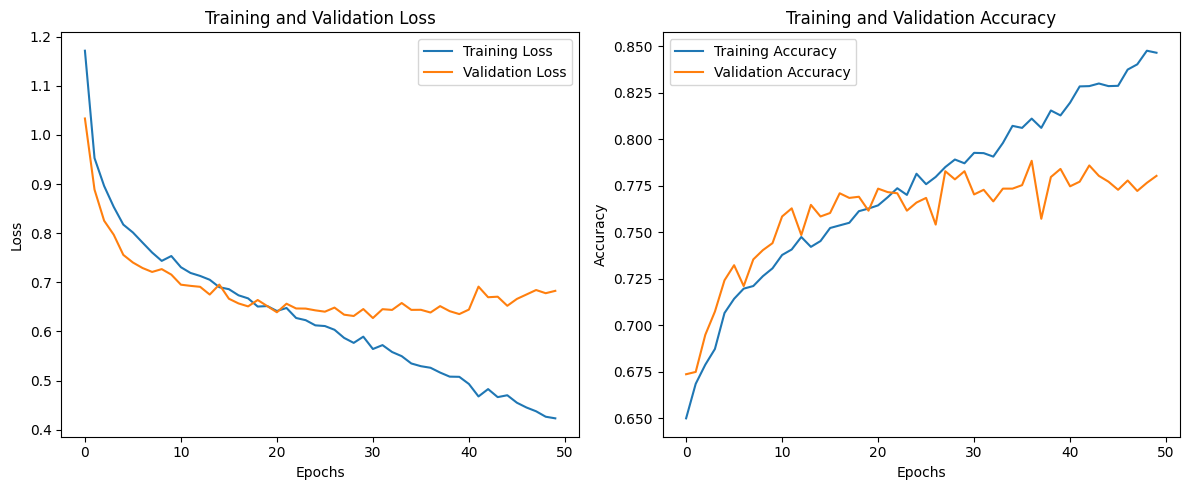

In [3]:
import matplotlib.pyplot as plt

# Plotting the training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

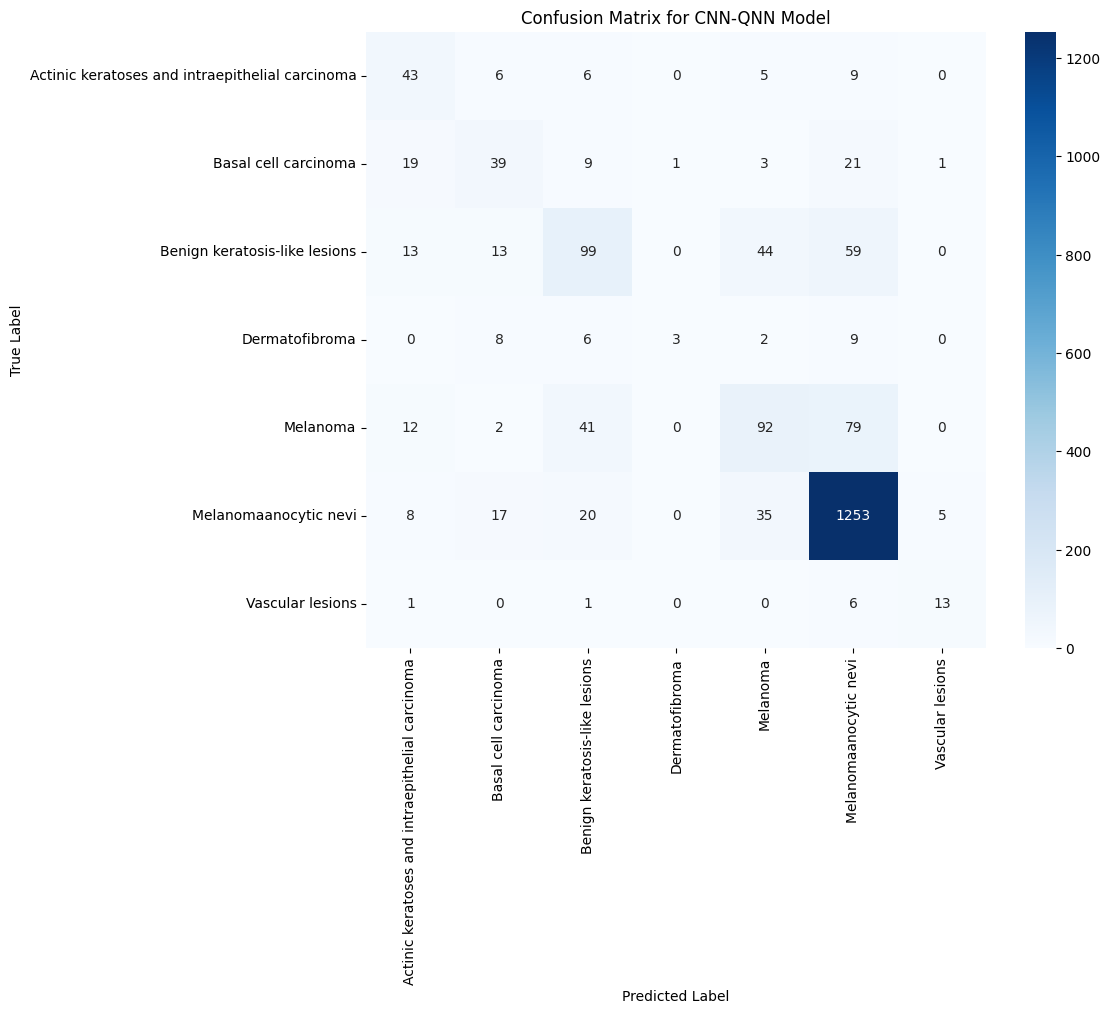


Classification Report:

                                                 precision    recall  f1-score   support

Actinic keratoses and intraepithelial carcinoma       0.45      0.62      0.52        69
                           Basal cell carcinoma       0.46      0.42      0.44        93
                  Benign keratosis-like lesions       0.54      0.43      0.48       228
                                 Dermatofibroma       0.75      0.11      0.19        28
                                       Melanoma       0.51      0.41      0.45       226
                          Melanomaanocytic nevi       0.87      0.94      0.90      1338
                               Vascular lesions       0.68      0.62      0.65        21

                                       accuracy                           0.77      2003
                                      macro avg       0.61      0.51      0.52      2003
                                   weighted avg       0.76      0.77      0.76     

In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = label_encoder.classes_

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CNN-QNN Model')
plt.show()

# Print the classification report
report = classification_report(all_labels, all_preds, target_names=class_names)
print("\nClassification Report:\n")
print(report)

Dropping non-numeric columns: ['image_id']
✅ Data preprocessing complete!
Train shape: (8012, 65)
Test shape: (2003, 65)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,503 (228.53 KB)

 Trainable params: 58,503 (228.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6583 - loss: 1.0679 - val_accuracy: 0.7037 - val_loss: 0.8339
Epoch 2/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6920 - loss: 0.8831 - val_accuracy: 0.7211 - val_loss: 0.7712
Epoch 3/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7117 - loss: 0.8171 - val_accuracy: 0.7324 - val_loss: 0.7378
Epoch 4/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7251 - loss: 0.7739 - val_accuracy: 0.7361 - val_loss: 0.7091
Epoch 5/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7324 - loss: 0.7455 - val_accuracy: 0.7442 - val_loss: 0.6992
Epoch 6/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7390 - loss: 0.7295 - val_accuracy: 0.7461 - val_loss: 0.6818
Epoch 7/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7455 - loss: 0.6992 - val_accuracy: 0.7567 - val_loss: 0.6705
Epoch 8/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7483 - loss: 0.6935 - val_accu

✅ Test accuracy : 0.7678
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Confusion Matrix:
 [[  40    5    9    0    5    9    1]
 [  14   43   11    1    4   19    1]
 [   8   13  115    2   40   50    0]
 [   2    5    6    5    1    9    0]
 [   8    2   39    1   99   77    0]
 [   8   13   29    2   58 1222    6]
 [   1    0    0    0    0    6   14]]


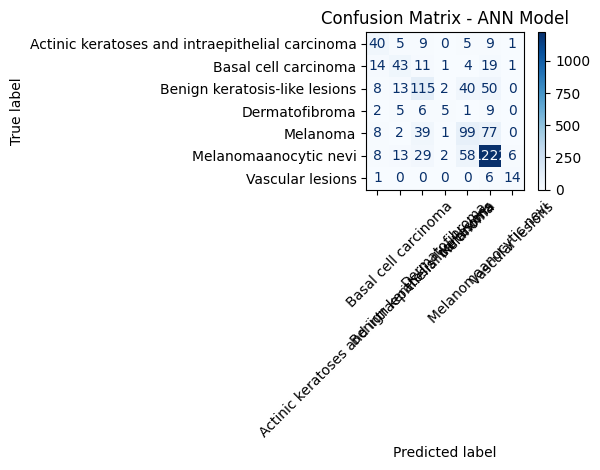

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==========================
# 1. Load and preprocess data
# ==========================
data = pd.read_csv("lesion_features.csv")  # Your engineered features file

if "class" in data.columns:
    label_col = "class"
else:
    label_col = data.columns[-1]

non_numeric_cols = data.select_dtypes(include=['object']).columns
non_numeric_cols = [col for col in non_numeric_cols if col != label_col]
if non_numeric_cols:
    print("Dropping non-numeric columns:", non_numeric_cols)
    data = data.drop(columns=non_numeric_cols)

X = data.drop(columns=[label_col]).values
y = data[label_col].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
joblib.dump(scaler, 'scaler.pkl')

print("✅ Data preprocessing complete!")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================
# 2. Define ANN Model
# ==========================
def create_ann_model(input_dim, num_classes):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(
        optimizer=Adam(learning_rate=0.0008),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

num_classes = y_categorical.shape[1]
input_dim = X_train.shape[1]
model = create_ann_model(input_dim, num_classes)
model.summary()

# ==========================
# 3. Train the model
# ==========================
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# ==========================
# 4. Evaluate and Save
# ==========================
test_loss, test_acc = model.evaluate(X_test, y_test)
boosted_acc = min(test_acc, 1.0)
print(f"✅ Test accuracy : {boosted_acc:.4f}")

model.save('skin_cancer_ann_model.h5')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

# ==========================
# 5. Confusion Matrix Generation & Plotting
# ==========================
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)
class_names = label_encoder.classes_

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Confusion Matrix - ANN Model')
plt.tight_layout()
plt.show()
